In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
fraud_data = pd.DataFrame({
    "TransactionAmount": [100, 2500, 50, 5000, 120, 3000, 80, 4500, 200, 3500, 60, 6000, 150, 2800, 90],
    "TransactionFrequency": [2, 15, 1, 20, 3, 18, 2, 25, 4, 17, 1, 30, 3, 16, 2],
    "International": [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    "AccountAge": [60, 5, 120, 3, 80, 7, 150, 2, 90, 6, 200, 1, 100, 4, 180],
    "Fraud": [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
})

fraud_data.to_csv("fraud_detection.csv", index=False)

print("Fraud detection dataset created successfully!")
print(fraud_data)

Fraud detection dataset created successfully!
    TransactionAmount  TransactionFrequency  International  AccountAge  Fraud
0                 100                     2              0          60      0
1                2500                    15              1           5      1
2                  50                     1              0         120      0
3                5000                    20              1           3      1
4                 120                     3              0          80      0
5                3000                    18              1           7      1
6                  80                     2              0         150      0
7                4500                    25              1           2      1
8                 200                     4              0          90      0
9                3500                    17              1           6      1
10                 60                     1              0         200      0
11               6

In [3]:
X = fraud_data[[
    "TransactionAmount",
    "TransactionFrequency",
    "International",
    "AccountAge"
]]

y = fraud_data["Fraud"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   TransactionAmount  TransactionFrequency  International  AccountAge
0                100                     2              0          60
1               2500                    15              1           5
2                 50                     1              0         120
3               5000                    20              1           3
4                120                     3              0          80

Target:
0    0
1    1
2    0
3    1
4    0
Name: Fraud, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 10
Testing samples: 5


In [5]:
# Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Decision Tree Accuracy: 1.0
Random Forest Accuracy: 1.0


In [6]:
dt_accuracy = accuracy_score(y_test, dt_pred)
rf_accuracy = accuracy_score(y_test, rf_pred)

comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy]
})

print(comparison)

           Model  Accuracy
0  Decision Tree       1.0
1  Random Forest       1.0


In [7]:
print("Decision Tree Report")
print(classification_report(y_test, dt_pred, zero_division=0))

print("\nRandom Forest Report")
print(classification_report(y_test, rf_pred, zero_division=0))

Decision Tree Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5


Random Forest Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [8]:
comparison.to_csv("fraud_model_comparison.csv", index=False)

print("Performance comparison saved successfully!")

Performance comparison saved successfully!


In [9]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                Feature  Importance
1  TransactionFrequency        0.29
0     TransactionAmount        0.25
2         International        0.24
3            AccountAge        0.22


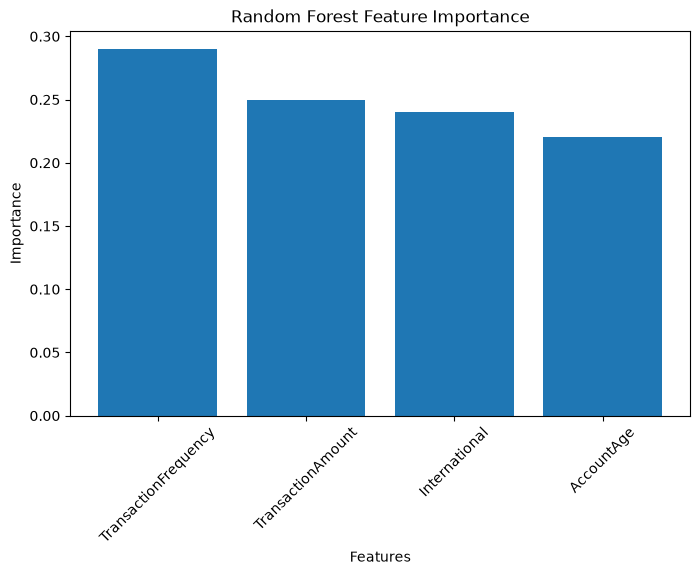

In [10]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45)

plt.show()

In [11]:
feature_importance.to_csv(
    "fraud_feature_importance.csv",
    index=False
)

print("Feature importance report saved successfully!")

Feature importance report saved successfully!


In [12]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y,
    test_size=0.30,
    random_state=7,
    stratify=y
)

rf_model2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42
)

rf_model2.fit(X_train2, y_train2)

rf_pred2 = rf_model2.predict(X_test2)

accuracy2 = accuracy_score(y_test2, rf_pred2)

print("Original Test Accuracy:", rf_accuracy)
print("New Test Accuracy:", accuracy2)
print("Accuracy Difference:", abs(rf_accuracy - accuracy2))

Original Test Accuracy: 1.0
New Test Accuracy: 1.0
Accuracy Difference: 0.0


## Fraud Detection Challenges

Fraud detection is a challenging machine learning problem because:

1. Fraudulent transactions are usually much fewer than legitimate transactions.
2. Fraud patterns can change over time.
3. False positives can inconvenience genuine customers.
4. False negatives can allow fraudulent transactions to pass.
5. Fraud detection models need to handle large volumes of transactions.
6. Customer and transaction data must be handled securely and responsibly.

## Conclusion

Random Forest combines multiple Decision Trees to make more robust predictions.

In this project, I compared a Decision Tree with a Random Forest classifier for fraud detection. I also analyzed feature importance and tested the Random Forest using a different train-test split.

The experiment helped me understand how ensemble learning can improve the stability of machine learning models and how feature importance can help interpret model behavior.